<a href="https://colab.research.google.com/github/Not-kh-lily-23/pulsar-conformal-triage/blob/main/main_triage_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
success
now we will train
probabilities are generated now we'll start caliberation
caliberation


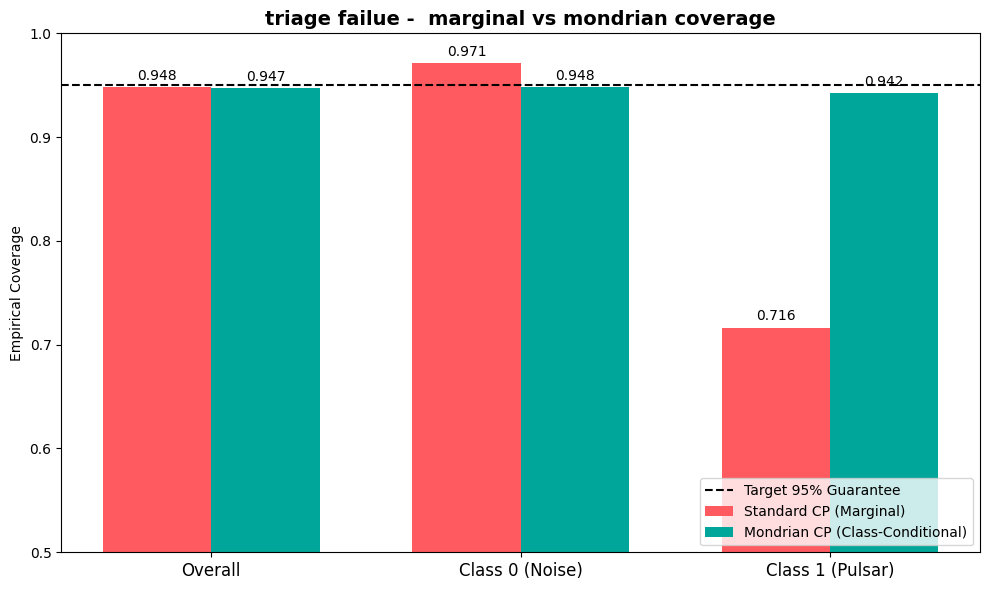

class 0 (noise) coverage: 0.9501 [95% CI: 0.9429 - 0.9562]
class 1 (pulsar) overage: 0.9305 [95% CI: 0.9069 - 0.9467]
overall coverage: 0.9483 [95% CI: 0.9409 - 0.9535]
Standard ML - wasted Ops (FP): 25, missed pulsars (FN): 47
Mondrian CP - wasted Ops (FP): 169, missed pulsars (FN): 19, deferred: 319
Standard ML fixed wasted hours: 6.25 hrs
Mondrian CP fixed wasted hours: 58.20 hrs
balanced ml - wasted ops (FP): 49, missed pulsars (FN): 34
balanced ml fixed wasted hours: 12.25 hrs


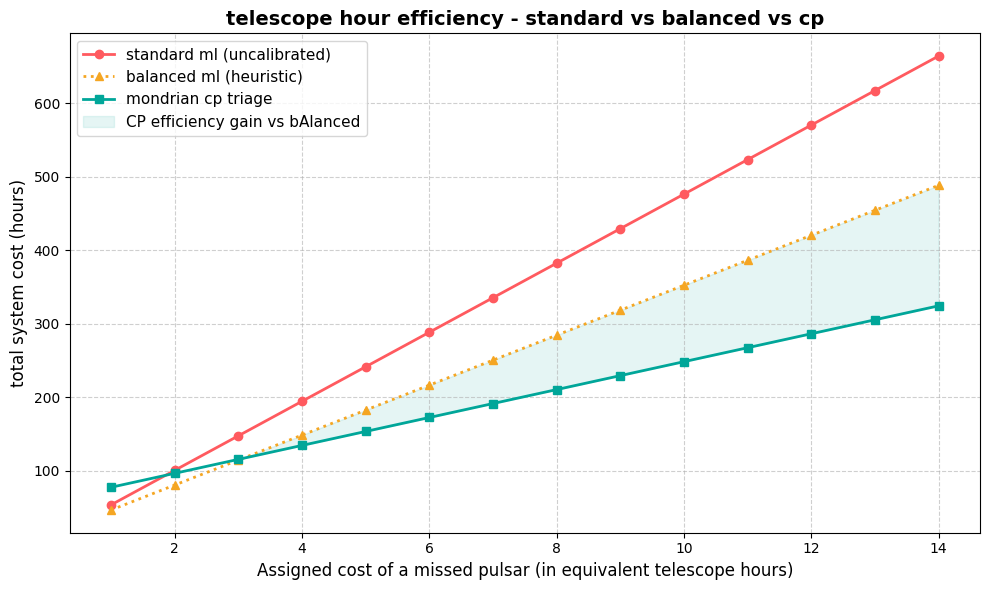

If missing a real pulsar is considered worse than wasting 2 hours of telescope time, Mondrian CP is the therefore a mathematically cheaper system.


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')
processed='/content/drive/MyDrive/pulsar_project/data/processed'
try:
    trn_df=pd.read_csv(f"{processed}/train.csv")
    calib_df=pd.read_csv(f"{processed}/calib.csv")
    tst_df=pd.read_csv(f"{processed}/test.csv")
    print("success")
except FileNotFoundError:
    raise Exception("data not found")
x_train,y_train=trn_df.drop(columns=["target"]),trn_df["target"]
x_calib,y_calib=calib_df.drop(columns=["target"]),calib_df["target"]
x_test,y_test=tst_df.drop(columns=["target"]),tst_df["target"]
print("now we will train")
clf=lgb.LGBMClassifier(random_state=42,n_estimators=100,verbose=-1)
clf.fit(x_train,y_train)
calib_probs=clf.predict_proba(x_calib)
test_probs=clf.predict_proba(x_test)
print("probabilities are generated now we'll start caliberation")
print("caliberation")
calib_scores=1-calib_probs[np.arange(len(y_calib)),y_calib]
tstc=1-test_probs[np.arange(len(y_test)),y_test]
alpha=0.05
n=len(y_calib)
q_level=np.ceil((n+1)*(1-alpha))/n
marg_q=np.quantile(calib_scores,min(1.0,q_level))
marg_cov_0=np.mean(tstc[y_test==0]<=marg_q)
marg_cov_1=np.mean(tstc[y_test==1]<=marg_q)
marg_cov_overall=np.mean(tstc<=marg_q)
scores_0=calib_scores[y_calib==0]
scores_1=calib_scores[y_calib==1]
n_0=len(scores_0)
q_level_0=np.ceil((n_0+1)*(1-alpha))/n_0
q_0=np.quantile(scores_0,min(1.0,q_level_0))
n_1=len(scores_1)
q_level_1=np.ceil((n_1+1)*(1-alpha))/n_1
q_1=np.quantile(scores_1,min(1.0,q_level_1))
mdr_cov_0=np.mean(tstc[y_test==0]<=q_0)
mdr_cov_1=np.mean(tstc[y_test==1]<=q_1)
mdr_cov_overall=np.mean(tstc<=np.where(y_test==0,q_0,q_1))
labels=['Overall','Class 0 (Noise)','Class 1 (Pulsar)']
marg_bars=[marg_cov_overall,marg_cov_0,marg_cov_1]
mdr_bars=[mdr_cov_overall,mdr_cov_0,mdr_cov_1]
x=np.arange(len(labels))
width=0.35
fig,ax=plt.subplots(figsize=(10, 6))
rects1=ax.bar(x-width/2,marg_bars,width,label='Standard CP (Marginal)',color='#ff5a5f')
rects2=ax.bar(x+width/2,mdr_bars,width,label='Mondrian CP (Class-Conditional)',color='#00a699')
ax.axhline(y=0.95,color='black',linestyle='--',label='Target 95% Guarantee')
ax.set_ylabel('Empirical Coverage')
ax.set_title('triage failue -  marginal vs mondrian coverage',fontsize=14,fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=12)
ax.set_ylim(0.5,1.0)
ax.legend(loc='lower right')
for rect in rects1 + rects2:
    height=rect.get_height()
    ax.annotate(f'{height:.3f}',xy=(rect.get_x()+rect.get_width()/2,height),
                xytext=(0, 3),textcoords="offset points",ha='center',va='bottom',fontsize=10)
plt.tight_layout()
plt.show()
n_iter=20
alpha=0.05
cov_overall_list=[]
cov_0_list=[]
cov_1_list=[]
tstc=1-test_probs[np.arange(len(y_test)),y_test]
calib_scores=1-calib_probs[np.arange(len(y_calib)),y_calib]
x_pool=pd.concat([x_train,x_calib])
y_pool=pd.concat([y_train,y_calib])
cov_0_list_rt=[]
cov_1_list_rt=[]
cov_overall_list_rt=[]
for seed in range(20):
    xtrs,xcals,ytrs,ycals=train_test_split(x_pool,y_pool,test_size=len(y_calib),random_state=seed,stratify=y_pool)
    clf_seed=lgb.LGBMClassifier(random_state=seed,n_estimators=100,verbose=-1)
    clf_seed.fit(xtrs, ytrs)
    calib_prob_s=clf_seed.predict_proba(xcals)
    calib_score_s=1-calib_prob_s[np.arange(len(ycals)),ycals]
    test_prob_s=clf_seed.predict_proba(x_test)
    tstc_s=1-test_prob_s[np.arange(len(y_test)),y_test]
    scores0_s=calib_score_s[ycals==0]
    n0_s=len(scores0_s)
    q0_s=np.quantile(scores0_s,min(1.0, np.ceil((n0_s+1)*(1-0.05))/n0_s))
    scores1_s=calib_score_s[ycals==1]
    n1_s=len(scores1_s)
    q1_s=np.quantile(scores1_s,min(1.0, np.ceil((n1_s+1)*(1-0.05))/n1_s))
    cov0_s=np.mean(tstc_s[y_test==0]<=q0_s)
    cov1_s=np.mean(tstc_s[y_test==1]<=q1_s)
    cov_overall_s=np.mean(tstc_s<=np.where(y_test==0,q0_s,q1_s))
    cov_0_list_rt.append(cov0_s)
    cov_1_list_rt.append(cov1_s)
    cov_overall_list_rt.append(cov_overall_s)
print(f"class 0 (noise) coverage: {np.mean(cov_0_list_rt):.4f} [95% CI: {np.percentile(cov_0_list_rt,2.5):.4f} - {np.percentile(cov_0_list_rt,97.5):.4f}]")
print(f"class 1 (pulsar) overage: {np.mean(cov_1_list_rt):.4f} [95% CI: {np.percentile(cov_1_list_rt,2.5):.4f} - {np.percentile(cov_1_list_rt,97.5):.4f}]")
print(f"overall coverage: {np.mean(cov_overall_list_rt):.4f} [95% CI: {np.percentile(cov_overall_list_rt,2.5):.4f} - {np.percentile(cov_overall_list_rt,97.5):.4f}]")
def gen_predsets(test_probs,q_0,q_1):
    inc_0=(1-test_probs[:,0])<=q_0
    inc_1=(1-test_probs[:,1])<=q_1
    labels=[]
    for i0, i1 in zip(inc_0,inc_1):
        if i0 and not i1:
            labels.append("discard (definitive noise)")
        elif not i0 and i1:
            labels.append("telescope (definitive pulsar)")
        elif i0 and i1:
            labels.append("defer (ambiguous)")
        else:
            labels.append("anomaly (empty set)")
    return np.array(labels)
triage_des=gen_predsets(test_probs,q_0,q_1)
rdf=pd.DataFrame({
    'true_label':y_test.values,
    'prob_pulsar':test_probs[:, 1],
    'triage_decision':triage_des
})
standard_preds=(test_probs[:,1]>=0.5).astype(int)
std_fp=np.sum((standard_preds==1)&(y_test==0))
std_fn=np.sum((standard_preds==0)&(y_test==1))
cp_fp=np.sum((rdf['triage_decision']=="telescope (definitive pulsar)")&(rdf['true_label']==0))
cp_fn=np.sum((rdf['triage_decision']=="discard (definitive noise)")&(rdf['true_label']==1))
cp_deferrals=np.sum(rdf['triage_decision']=="defer (ambiguous)")
print(f"Standard ML - wasted Ops (FP): {std_fp}, missed pulsars (FN): {std_fn}")
print(f"Mondrian CP - wasted Ops (FP): {cp_fp}, missed pulsars (FN): {cp_fn}, deferred: {cp_deferrals}")
cost_telescope_pointing=0.25
cost_human_review=0.05
std_wasted_hours=std_fp*cost_telescope_pointing
cp_wasted_hours=(cp_fp*cost_telescope_pointing)+(cp_deferrals*cost_human_review)
print(f"Standard ML fixed wasted hours: {std_wasted_hours:.2f} hrs")
print(f"Mondrian CP fixed wasted hours: {cp_wasted_hours:.2f} hrs")
missed_pulsar_penalties=np.arange(1,15,1)
std_total_costs=[]
cp_total_costs=[]
missed_pulsar_penalties=np.arange(1,15,1)
std_total_costs=[]
cp_total_costs=[]
clf_balanced=lgb.LGBMClassifier(random_state=42,n_estimators=100,class_weight='balanced',verbose=-1)
clf_balanced.fit(x_train,y_train)
balanced_preds=clf_balanced.predict(x_test)
bal_fp=np.sum((balanced_preds==1)&(y_test==0))
bal_fn=np.sum((balanced_preds==0)&(y_test==1))
bal_wasted_hours=bal_fp*cost_telescope_pointing
print(f"balanced ml - wasted ops (FP): {bal_fp}, missed pulsars (FN): {bal_fn}")
print(f"balanced ml fixed wasted hours: {bal_wasted_hours:.2f} hrs")
std_total_costs=[]
cp_total_costs=[]
bal_total_costs=[]
for penalty in missed_pulsar_penalties:
    cost_std=std_wasted_hours+(std_fn*penalty)
    cost_cp=cp_wasted_hours+(cp_fn*penalty)
    cost_bal=bal_wasted_hours+(bal_fn*penalty)
    std_total_costs.append(cost_std)
    cp_total_costs.append(cost_cp)
    bal_total_costs.append(cost_bal)
fig, ax=plt.subplots(figsize=(10,6))
ax.plot(missed_pulsar_penalties,std_total_costs,marker='o',label='standard ml (uncalibrated)',color='#ff5a5f',linewidth=2)
ax.plot(missed_pulsar_penalties,bal_total_costs,marker='^',label='balanced ml (heuristic)',color='#f5a623',linewidth=2,linestyle=':')
ax.plot(missed_pulsar_penalties,cp_total_costs,marker='s',label='mondrian cp triage',color='#00a699',linewidth=2)
ax.fill_between(missed_pulsar_penalties,bal_total_costs,cp_total_costs,where=(np.array(bal_total_costs)>np.array(cp_total_costs)),interpolate=True,color='#00a699',alpha=0.1,label='CP efficiency gain vs bAlanced')
ax.set_xlabel('Assigned cost of a missed pulsar (in equivalent telescope hours)', fontsize=12)
ax.set_ylabel('total system cost (hours)',fontsize=12)
ax.set_title('telescope hour efficiency - standard vs balanced vs cp',fontsize=14,fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()
diffs=np.array(std_total_costs)-np.array(cp_total_costs)
bei=np.where(diffs>0)[0]
if len(bei)>0:
    bep=missed_pulsar_penalties[bei[0]]
    print(f"If missing a real pulsar is considered worse than wasting {bep} hours of telescope time, Mondrian CP is the therefore a mathematically cheaper system.")
else:
    print("Mondrian CP requires a higher penalty ratio to break even on this dataset.")